<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/03_BERT_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch --quiet

In [2]:
# Standard library
import os
import random

# Data handling
import numpy as np
import pandas as pd


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Hugging Face
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

from transformers import BertTokenizer, BertModel
import torch

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


For fine-tuning, I selected `bert-base-uncased` because the dataset is relatively small and the main priority is classification quality rather than training speed. BERT is a strong pretrained transformer model that can capture contextual meaning in support ticket texts better than traditional baseline models.


In [4]:
DATA_PATH = "/content/customer_support_tickets_cleaned.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run the preprocessing notebook first or upload the cleaned CSV file."
    )

df = pd.read_csv(DATA_PATH)

df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [5]:
df.shape

(28261, 7)

In [6]:
df[["text", "queue"]].isna().sum()

,0
text,0
queue,0


In [7]:
df["queue"].value_counts()

,count
queue,
Technical Support,8149
Product Support,5305
Customer Service,4269
IT Support,3333
Billing and Payments,2897
Returns and Exchanges,1402
Service Outages and Maintenance,1106
Sales and Pre-Sales,843
Human Resources,553


In [8]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["queue"])

In [9]:
pd.DataFrame({
    "Class": label_encoder.classes_,
    "Label": range(len(label_encoder.classes_))
})

,Class,Label
0,Billing and Payments,0
1,Customer Service,1
2,General Inquiry,2
3,Human Resources,3
4,IT Support,4
5,Product Support,5
6,Returns and Exchanges,6
7,Sales and Pre-Sales,7
8,Service Outages and Maintenance,8
9,Technical Support,9


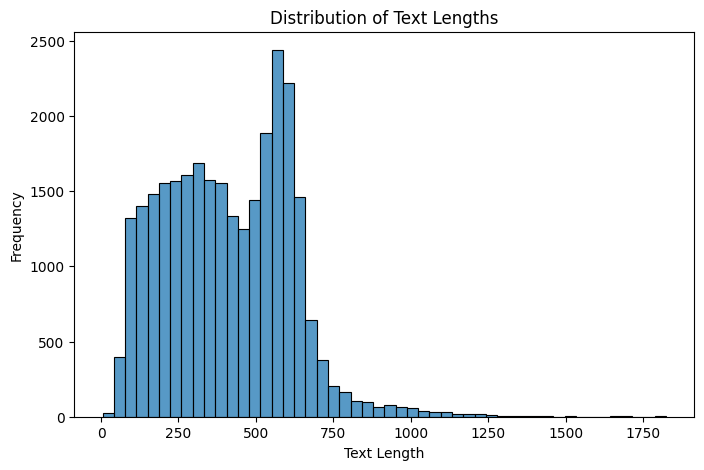

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['text'].apply(len), bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [11]:
X = df["text"]
y = df["label"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

In [14]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [15]:
token_lengths = df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x)) + 2
)

token_lengths.describe()

,text
count,28261.000000
mean,75.276529
std,38.990666
min,3.000000
25%,44.000000
50%,73.000000
75%,103.000000
max,419.000000


In [16]:
(token_lengths > 128).mean() * 100

np.float64(5.902126605569513)

Only about 5.9% of ticket texts exceed 128 BERT tokens. However, since the goal is to preserve as much context as possible for better classification quality, the maximum sequence length was set to 256 tokens. This value provides a good trade-off between information retention and computational efficiency.

In [17]:
max_length = 256

In [18]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

In [19]:
class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [20]:
train_dataset = TicketDataset(train_encodings, y_train)
val_dataset = TicketDataset(val_encodings, y_val)
test_dataset = TicketDataset(test_encodings, y_test)

In [21]:
train_dataset[0].keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np
from transformers import Trainer

classes = np.arange(len(label_encoder.classes_))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.to_numpy()
)

class_weights = torch.tensor(weights, dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [24]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./bert_ticket_router",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_dir="./logs",
    logging_steps=100,

    save_total_limit=2,
    report_to="none",

    seed=SEED,
    fp16=torch.cuda.is_available()
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [26]:
model= AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


When loading bert-base-uncased for sequence classification, some pretrained heads related to masked language modeling and next sentence prediction are not used. At the same time, the new classification layer is randomly initialized because the pretrained checkpoint does not contain task-specific weights for the support ticket categories. This is expected and the classification head will be learned during fine-tuning.

In [27]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.775300,1.806600,0.279080,0.277920,0.337937,0.272694,0.334559,0.279080,0.253711
2,1.677148,1.572060,0.437859,0.466456,0.450366,0.446942,0.444908,0.437859,0.433596
3,1.123681,1.423178,0.501990,0.512586,0.541030,0.522288,0.513316,0.501990,0.501035
4,0.793699,1.400351,0.581159,0.651453,0.603122,0.615271,0.595817,0.581159,0.582490
5,0.537356,1.371027,0.624060,0.656498,0.638111,0.643162,0.626704,0.624060,0.622476
6,0.315119,1.420026,0.649713,0.673704,0.656515,0.663174,0.650098,0.649713,0.649286


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=15264, training_loss=1.1064333898216423, metrics={'train_runtime': 2127.4366, 'train_samples_per_second': 57.385, 'train_steps_per_second': 7.175, 'total_flos': 1.6061715540670464e+16, 'train_loss': 1.1064333898216423, 'epoch': 6.0})

In [31]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.315119,1.420026,6,0.649713,0.673704,0.656515,0.663174,0.650098,0.649713,0.649286


{'eval_loss': 1.4200257062911987,
 'eval_accuracy': 0.6497125165855816,
 'eval_macro_precision': 0.673704078156821,
 'eval_macro_recall': 0.6565151190018225,
 'eval_macro_f1': 0.663173901582095,
 'eval_weighted_precision': 0.6500981474906615,
 'eval_weighted_recall': 0.6497125165855816,
 'eval_weighted_f1': 0.6492864532243747}

In [32]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    y_test.reset_index(drop=True),
    y_pred,
    target_names=label_encoder.classes_
))

print("Macro F1:", f1_score(
    y_test.reset_index(drop=True),
    y_pred,
    average="macro"
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.86      0.84       579
               Customer Service       0.59      0.62      0.61       854
                General Inquiry       0.59      0.56      0.57        81
                Human Resources       0.72      0.73      0.73       111
                     IT Support       0.58      0.61      0.60       667
                Product Support       0.58      0.59      0.58      1061
          Returns and Exchanges       0.69      0.66      0.67       280
            Sales and Pre-Sales       0.67      0.59      0.63       169
Service Outages and Maintenance       0.74      0.81      0.77       221
              Technical Support       0.67      0.63      0.65      1630

                       accuracy                           0.65      5653
                      macro avg       0.67      0.66      0.67      5653
                   weighted avg       0.65      0

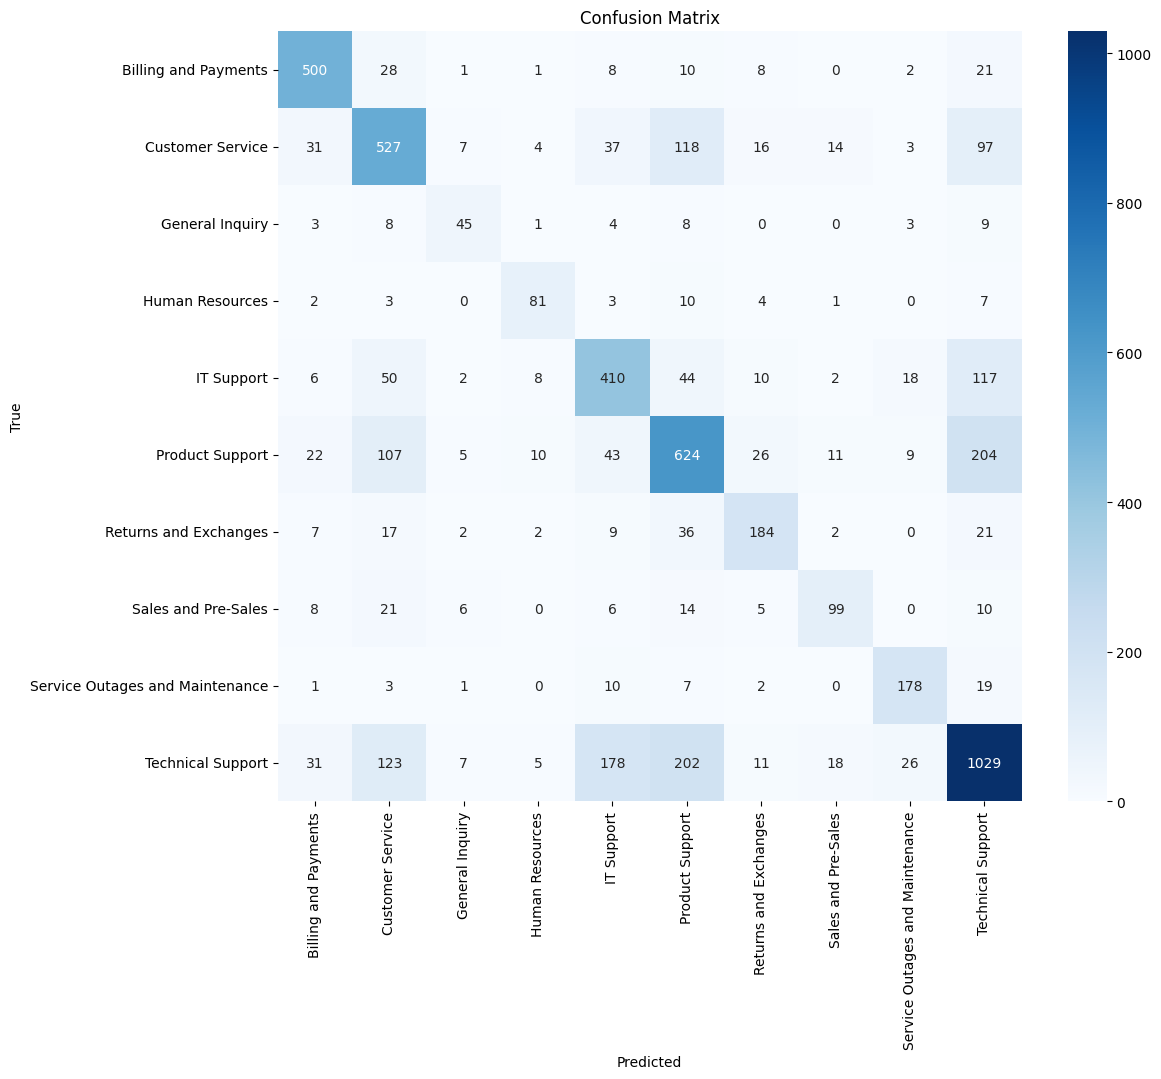

In [33]:
cm = confusion_matrix(y_test.reset_index(drop=True), y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Error Analysis

In [34]:
y_true = y_test.reset_index(drop=True).to_numpy()
logits = predictions.predictions

# probabilities for each class
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

# predicted confidence
pred_confidence = probs.max(axis=1)

# probability assigned to the true class
true_class_probability = probs[np.arange(len(y_true)), y_true]

# top-2 margin: наскільки модель була впевнена у своєму виборі
sorted_probs = np.sort(probs, axis=1)
confidence_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

result_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label_id": y_true,
    "predicted_label_id": y_pred,
    "true_label": label_encoder.inverse_transform(y_true),
    "predicted_label": label_encoder.inverse_transform(y_pred),
    "is_error": y_true != y_pred,
    "pred_confidence": pred_confidence,
    "true_class_probability": true_class_probability,
    "confidence_margin": confidence_margin
})

result_df.head()

,text,true_label_id,predicted_label_id,true_label,predicted_label,is_error,pred_confidence,true_class_probability,confidence_margin
0,Improve Digital Marketing Strategies with Enha...,9,9,Technical Support,Technical Support,False,0.837778,0.837778,0.770339
1,Security Protocols Following a Data Breach in ...,6,9,Returns and Exchanges,Technical Support,True,0.542211,0.012296,0.320555
2,Problem with Today's Uploads in PDFfiller We a...,9,9,Technical Support,Technical Support,False,0.692405,0.692405,0.438677
3,Strategies for Brand Growth in the Digital Spa...,1,1,Customer Service,Customer Service,False,0.400765,0.400765,0.139982
4,Trouble with ClickUp Integration Smart-Thermom...,9,9,Technical Support,Technical Support,False,0.932149,0.932149,0.897186


In [35]:
total = len(result_df)
errors_count = result_df["is_error"].sum()
correct_count = total - errors_count

print("Total examples:", total)
print("Correct predictions:", correct_count)
print("Errors:", errors_count)
print("Error rate:", errors_count / total)

Total examples: 5653
Correct predictions: 3677
Errors: 1976
Error rate: 0.34954891208208033


In [36]:
per_class_errors = (
    result_df
    .groupby("true_label")
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

per_class_errors["error_rate"] = per_class_errors["errors"] / per_class_errors["total"]

per_class_errors = per_class_errors.sort_values("error_rate", ascending=False)

per_class_errors

,true_label,total,errors,avg_confidence,error_rate
2,General Inquiry,81,36,0.836336,0.444444
7,Sales and Pre-Sales,169,70,0.831381,0.414201
5,Product Support,1061,437,0.739684,0.411876
4,IT Support,667,257,0.822075,0.385307
1,Customer Service,854,327,0.753114,0.382904
9,Technical Support,1630,601,0.741845,0.368712
6,Returns and Exchanges,280,96,0.856680,0.342857
3,Human Resources,111,30,0.890286,0.270270
8,Service Outages and Maintenance,221,43,0.920880,0.194570
0,Billing and Payments,579,79,0.929654,0.136442


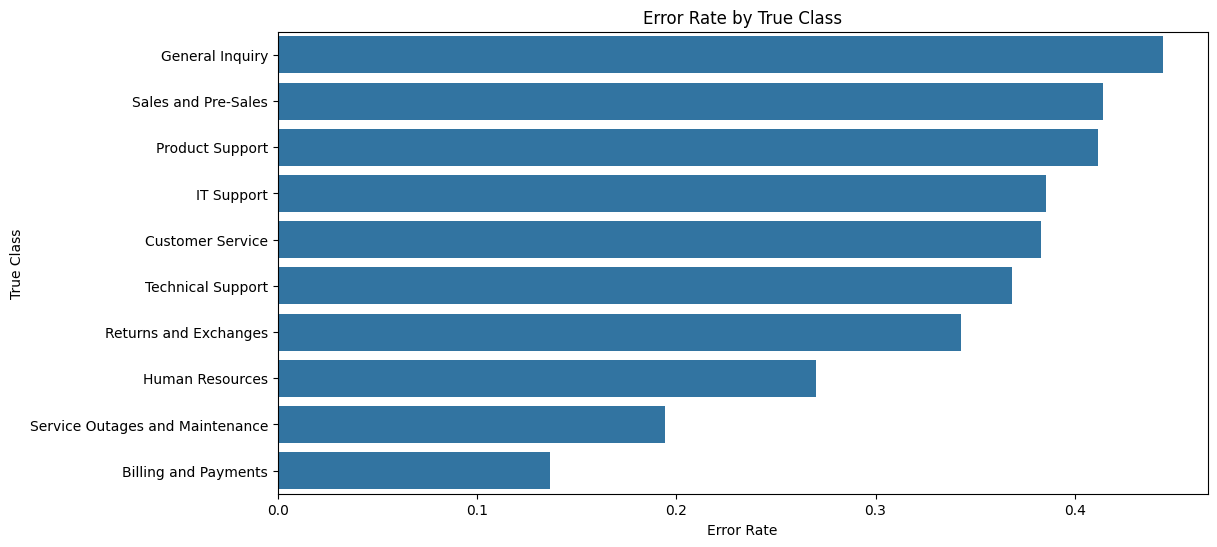

In [37]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=per_class_errors,
    x="error_rate",
    y="true_label"
)

plt.xlabel("Error Rate")
plt.ylabel("True Class")
plt.title("Error Rate by True Class")
plt.show()

In [38]:
errors_df = result_df[result_df["is_error"]].copy()

confusion_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .agg(
        count=("text", "size"),
        avg_confidence=("pred_confidence", "mean"),
        avg_true_class_probability=("true_class_probability", "mean")
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

confusion_pairs.head(20)

,true_label,predicted_label,count,avg_confidence,avg_true_class_probability
48,Product Support,Technical Support,204,0.689650,0.186012
76,Technical Support,Product Support,202,0.624600,0.212164
75,Technical Support,IT Support,178,0.753947,0.182317
72,Technical Support,Customer Service,123,0.658410,0.131956
12,Customer Service,Product Support,118,0.658782,0.157463
39,IT Support,Technical Support,117,0.692714,0.150372
41,Product Support,Customer Service,107,0.679734,0.161600
16,Customer Service,Technical Support,97,0.626337,0.103358
32,IT Support,Customer Service,50,0.681306,0.041068
35,IT Support,Product Support,44,0.658766,0.020450


In [39]:
def show_errors(true_class=None, predicted_class=None, n=10):
    subset = errors_df.copy()

    if true_class is not None:
        subset = subset[subset["true_label"] == true_class]

    if predicted_class is not None:
        subset = subset[subset["predicted_label"] == predicted_class]

    subset = subset.sort_values("pred_confidence", ascending=False)

    return subset[[
        "text",
        "true_label",
        "predicted_label",
        "pred_confidence",
        "true_class_probability",
        "confidence_margin"
    ]].head(n)

In [40]:
show_errors(
    true_class="Customer Service",
    predicted_class="Product Support",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
3829,Concern Over Brand Engagement Noted a sudden d...,Customer Service,Product Support,0.968430,0.010843,0.953258
345,Problem with Brand Engagement We have noticed ...,Customer Service,Product Support,0.963775,0.013003,0.942607
3658,Problem with Financial Data A financial compan...,Customer Service,Product Support,0.962941,0.007988,0.940028
121,"Improvement in Data Analytics Tools Hello, I a...",Customer Service,Product Support,0.952893,0.031727,0.921167
3461,Support for Integrating Project Management Too...,Customer Service,Product Support,0.941732,0.034437,0.907295
4542,A financial organization encountered data dis...,Customer Service,Product Support,0.928577,0.022864,0.887937
1489,Data Integration Challenge A financial organiz...,Customer Service,Product Support,0.927371,0.032107,0.895264
5121,Improvements in Data Analysis seek enhancement...,Customer Service,Product Support,0.926773,0.042590,0.884183
1944,Tools for Enhancing Team Collaboration in Proj...,Customer Service,Product Support,0.905208,0.053834,0.851374
3522,Request for Guidelines on Securing Medical Dat...,Customer Service,Product Support,0.902453,0.062624,0.839829


In [41]:
show_errors(
    true_class="General Inquiry",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
2389,Problem with Hospital System Security breach f...,General Inquiry,IT Support,0.977313,0.000478,0.965248
2470,Problem Accessing Medical Records Customer Sup...,General Inquiry,Product Support,0.954832,0.006648,0.931091
1095,Social Media Campaign Performance Issues Follo...,General Inquiry,Customer Service,0.954248,0.003548,0.927072
3430,Enhance Data Analytics Infrastructure Seek ass...,General Inquiry,IT Support,0.951255,0.000641,0.919829
5101,Server Facing problems with project dashboards...,General Inquiry,Product Support,0.899704,0.024617,0.842188
2397,System Glitch The data analytics platform unex...,General Inquiry,Technical Support,0.888612,0.000068,0.807081
3549,Concerns Regarding Scalable SaaS Project Manag...,General Inquiry,Customer Service,0.887427,0.004880,0.840670
952,Query Concerning Campaign Metrics Update I hop...,General Inquiry,Customer Service,0.880241,0.002185,0.774700
1384,Enhancement of Investment Portfolio Through An...,General Inquiry,Billing and Payments,0.867148,0.001650,0.781957
1880,Services in Data Analytics Is it possible to r...,General Inquiry,Billing and Payments,0.866486,0.049315,0.817170


In [42]:
result_df["char_length"] = result_df["text"].astype(str).apply(len)
result_df["token_length"] = result_df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x))
)

length_analysis = (
    result_df
    .assign(length_group=pd.cut(
        result_df["token_length"],
        bins=[0, 64, 128, 256, 512, 10000],
        labels=["0-64", "65-128", "129-256", "257-512", "512+"]
    ))
    .groupby("length_group", observed=False)
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

length_analysis["error_rate"] = length_analysis["errors"] / length_analysis["total"]

length_analysis

,length_group,total,errors,avg_confidence,error_rate
0,0-64,2495,888,0.792567,0.355912
1,65-128,2852,922,0.796476,0.323282
2,129-256,298,163,0.733612,0.546980
3,257-512,8,3,0.824833,0.375000
4,512+,0,0,NaN,NaN
